In [66]:
#  Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp
from pathlib import Path
from typing import Tuple, Dict
import warnings

pd.set_option('display.max_columns', 120)


In [67]:
# Paths and constants
BASE_DIR = Path('/Users/lena/Documents/hybrid_tugboat')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'data' / 'saved_figures'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Input files
INTEGRATED_CSV = PROCESSED_DIR / 'Integrated_OSG_DAT_Cleaned.csv'
DAT_1MIN_CSV = PROCESSED_DIR / 'DAT_1min.csv'
PORT_MISSIONS_ADV_CSV = PROCESSED_DIR / 'Port_Mission_Stats_Advanced.csv'
STBD_MISSIONS_ADV_CSV = PROCESSED_DIR / 'STBD_Mission_Stats_Advanced.csv'
MISSION_SUMMARY_CSV = PROCESSED_DIR / 'Mission_Summary_Table.csv'

# Output files
MISSION_FEATURES_CSV = PROCESSED_DIR / 'Mission_Features.csv'
MISSION_EMISSIONS_CSV = PROCESSED_DIR / 'Mission_Emissions.csv'
UTILIZATION_SUMMARY_CSV = PROCESSED_DIR / 'Engine_Utilization_Summary.csv'
ENGINE_MISSION_SUMMARY_CSV = PROCESSED_DIR / 'Engine_Mission_Summary.csv'
COMBINED_FIGURE_PNG = FIGURES_DIR / 'Combined_Engine_Performance_Missions.png'

# Analysis constants
TIME_COL = 'Unnamed: 0'
PORT = 'PORT'
STBD = 'STBD'
PORT_TEMP_COL = 'M/E PORT - Temperature'
STBD_TEMP_COL = 'M/E STBD - Temperature'
PORT_FUEL_TOTAL_COL = 'M/E PORT - Total Fuel'
STBD_FUEL_TOTAL_COL = 'M/E STBD - Total Fuel'
PORT_POWER_COL = 'Power_PORT_kW'
STBD_POWER_COL = 'Power_STBD_kW'
PORT_ENERGY_COL = 'Energy_Port_kWh'
STBD_ENERGY_COL = 'Energy_STBD_kWh'

# Utilization thresholds
POWER_ACTIVE_THRESHOLD_KW = 0.1
RPM_ACTIVE_THRESHOLD = 1.0  # if RPM columns are needed

# Emission factor (diesel-like fuel): kg CO2 per liter
# This constant is a standard order-of-magnitude factor used in absence of project-specific factors.
EMISSION_FACTOR_KG_CO2_PER_L = 2.68



In [68]:
# Helper functions

def _parse_timestamp_column(df: pd.DataFrame, time_col: str) -> pd.DataFrame:
    if time_col in df.columns:
        df = df.copy()
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        df = df.set_index(time_col).sort_index()
    else:
        # Assume index is already datetime-like
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(f"Timestamp column '{time_col}' not found and index is not DatetimeIndex")
        df = df.sort_index()
    return df


def robust_diff_nonnegative(series: pd.Series) -> pd.Series:
    """
    Compute non-negative per-interval deltas from a (mostly) cumulative series.
    Any negative diffs (resets/jumps) are coerced to 0.
    """
    diff = series.astype('float64').diff()
    diff.iloc[0] = 0.0
    diff[diff < 0] = 0.0
    return diff.fillna(0.0)


def compute_utilization(
    df: pd.DataFrame,
    power_col: str,
    rpm_col: str | None = None,
    power_threshold_kw: float = POWER_ACTIVE_THRESHOLD_KW,
    rpm_threshold: float = RPM_ACTIVE_THRESHOLD,
) -> Dict[str, float]:
    """
    Active if power > threshold OR (rpm_col provided and rpm > threshold).
    Returns active/idle minutes and percentages.
    """
    s_power = df.get(power_col)
    if s_power is None:
        raise KeyError(f"Column '{power_col}' not found in integrated dataset")

    active_power = s_power.fillna(0) > power_threshold_kw

    if rpm_col and rpm_col in df.columns:
        active_rpm = df[rpm_col].fillna(0) > rpm_threshold
        active = active_power | active_rpm
    else:
        active = active_power

    total = int(len(df))
    active_minutes = int(active.sum())
    idle_minutes = int(total - active_minutes)
    active_pct = (active_minutes / total) * 100 if total else 0.0
    idle_pct = 100.0 - active_pct if total else 0.0

    return {
        'active_minutes': active_minutes,
        'idle_minutes': idle_minutes,
        'active_pct': round(active_pct, 2),
        'idle_pct': round(idle_pct, 2),
        'total_minutes': total,
    }


def standardize_mission_df(df: pd.DataFrame, engine_label: str) -> pd.DataFrame:
    """
    Standardize mission stats columns to a unified schema across engines.
    Expected columns: mission_id, start_time, end_time, duration_minutes,
    total_energy (kWh), total_fuel (L), mean_temp (C), fuel_per_energy (L/kWh).
    """
    df = df.copy()
    # Rename mission id
    if 'Port_mission' in df.columns:
        df = df.rename(columns={'Port_mission': 'mission_id'})
    if 'STBD_mission' in df.columns:
        df = df.rename(columns={'STBD_mission': 'mission_id'})

    # Ensure types
    for col in ['start_time', 'end_time']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    if 'duration_minutes' in df.columns:
        df['duration_minutes'] = pd.to_numeric(df['duration_minutes'], errors='coerce')
    if 'total_energy' in df.columns:
        df['total_energy'] = pd.to_numeric(df['total_energy'], errors='coerce')
    if 'total_fuel' in df.columns:
        df['total_fuel'] = pd.to_numeric(df['total_fuel'], errors='coerce')
    if 'mean_temp' in df.columns:
        df['mean_temp'] = pd.to_numeric(df['mean_temp'], errors='coerce')
    if 'fuel_per_energy' in df.columns:
        df['fuel_per_energy'] = pd.to_numeric(df['fuel_per_energy'], errors='coerce')

    # Derived metrics
    df['energy_per_fuel_kwh_per_l'] = df['total_energy'].replace(0, np.nan) / df['total_fuel'].replace(0, np.nan)
    df['fuel_per_hour_lph'] = df['total_fuel'] / (df['duration_minutes'].replace(0, np.nan) / 60.0)

    # Flags for extremes (top 10%)
    df['is_high_energy'] = df['total_energy'] >= df['total_energy'].quantile(0.9)
    df['is_high_fuel'] = df['total_fuel'] >= df['total_fuel'].quantile(0.9)

    df.insert(0, 'engine', engine_label)

    # Order columns
    ordered_cols = [
        'engine', 'mission_id', 'start_time', 'end_time', 'duration_minutes',
        'total_energy', 'total_fuel', 'energy_per_fuel_kwh_per_l', 'fuel_per_hour_lph',
        'fuel_per_energy', 'mean_temp', 'is_high_energy', 'is_high_fuel'
    ]
    existing_cols = [c for c in ordered_cols if c in df.columns]
    return df[existing_cols].sort_values(['engine', 'mission_id'])


def emissions_from_fuel_liters(fuel_liters: pd.Series) -> pd.Series:
    return fuel_liters.fillna(0) * EMISSION_FACTOR_KG_CO2_PER_L


def add_mission_midpoint(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'start_time' in df.columns and 'end_time' in df.columns:
        df['mid_time'] = df['start_time'] + (df['end_time'] - df['start_time']) / 2
    return df



In [69]:
# Load datasets
with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=FutureWarning)

# Integrated 1-minute dataset
try:
    df_integrated = pd.read_csv(INTEGRATED_CSV)
    df_integrated = _parse_timestamp_column(df_integrated, TIME_COL)
except FileNotFoundError as e:
    raise FileNotFoundError(f"Integrated dataset not found at {INTEGRATED_CSV}") from e

# DAT 1-minute (optional for cross-checks)
try:
    df_dat_1min = pd.read_csv(DAT_1MIN_CSV)
    df_dat_1min = _parse_timestamp_column(df_dat_1min, TIME_COL)
except FileNotFoundError:
    df_dat_1min = None

# Mission stats (advanced)
try:
    df_port_missions = pd.read_csv(PORT_MISSIONS_ADV_CSV)
    df_stbd_missions = pd.read_csv(STBD_MISSIONS_ADV_CSV)
except FileNotFoundError as e:
    raise FileNotFoundError("Mission stats CSVs not found in processed directory") from e

# Mission summary (aggregated)
try:
    df_mission_summary = pd.read_csv(MISSION_SUMMARY_CSV)
except FileNotFoundError:
    df_mission_summary = None

print(f"Integrated shape: {df_integrated.shape}")
print(f"Port missions: {df_port_missions.shape}, STBD missions: {df_stbd_missions.shape}")



Integrated shape: (11520, 79)
Port missions: (54, 8), STBD missions: (22, 8)


In [70]:
# Utilization analysis (active vs idle)
util_port = compute_utilization(
    df_integrated, power_col=PORT_POWER_COL, rpm_col='RPM_PORT',
)
util_stbd = compute_utilization(
    df_integrated, power_col=STBD_POWER_COL, rpm_col='RPM_STBD',
)

util_df = pd.DataFrame([
    {'engine': PORT, **util_port},
    {'engine': STBD, **util_stbd},
]).set_index('engine')

util_df.to_csv(UTILIZATION_SUMMARY_CSV)
util_df


,active_minutes,idle_minutes,active_pct,idle_pct,total_minutes
engine,,,,,
PORT,2019,9501,17.53,82.47,11520
STBD,2583,8937,22.42,77.58,11520


In [71]:
# Mission features and efficiency KPIs
features_port = standardize_mission_df(df_port_missions, engine_label=PORT)
features_stbd = standardize_mission_df(df_stbd_missions, engine_label=STBD)

mission_features = pd.concat([features_port, features_stbd], ignore_index=True)

# Additional comparison-ready columns
mission_features['duration_hours'] = mission_features['duration_minutes'] / 60.0
mission_features['fuel_per_energy_l_per_kwh'] = mission_features['fuel_per_energy']

# Guard against inf/nan
mission_features = mission_features.replace([np.inf, -np.inf], np.nan)

# Save features
mission_features.to_csv(MISSION_FEATURES_CSV, index=False)
mission_features.head(10)


,engine,mission_id,start_time,end_time,duration_minutes,total_energy,total_fuel,energy_per_fuel_kwh_per_l,fuel_per_hour_lph,fuel_per_energy,mean_temp,is_high_energy,is_high_fuel,duration_hours,fuel_per_energy_l_per_kwh
0,PORT,1,2025-07-13 04:12:00,2025-07-13 06:44:00,153,532.234993,7.304847e+09,7.286052e-08,2.864646e+09,1.372485e+07,29.206771,True,True,2.550000,1.372485e+07
1,PORT,2,2025-07-13 20:35:00,2025-07-13 21:46:00,72,484.386670,3.438877e+09,1.408560e-07,2.865731e+09,7.099447e+06,28.318361,False,False,1.200000,7.099447e+06
2,PORT,3,2025-07-13 21:48:00,2025-07-13 21:51:00,4,0.491667,1.910781e+08,2.573121e-09,2.866171e+09,3.886331e+08,28.776257,False,False,0.066667,3.886331e+08
3,PORT,4,2025-07-14 03:29:00,2025-07-14 04:44:00,76,312.341672,3.630807e+09,8.602540e-08,2.866427e+09,1.162447e+07,29.076058,False,False,1.266667,1.162447e+07
4,PORT,5,2025-07-14 04:47:00,2025-07-14 04:48:00,2,0.278334,9.556041e+07,2.912650e-09,2.866812e+09,3.433300e+08,29.200012,False,False,0.033333,3.433300e+08
5,PORT,6,2025-07-14 12:31:00,2025-07-14 14:08:00,98,442.379997,4.683508e+09,9.445483e-08,2.867454e+09,1.058707e+07,29.276331,False,False,1.633333,1.058707e+07
6,PORT,7,2025-07-14 18:36:00,2025-07-14 20:21:00,106,904.588332,5.067531e+09,1.785067e-07,2.868414e+09,5.602030e+06,30.045036,True,False,1.766667,5.602030e+06
7,PORT,8,2025-07-14 20:23:00,2025-07-14 20:24:00,2,0.220000,9.565103e+07,2.300028e-09,2.869531e+09,4.347774e+08,30.938329,False,False,0.033333,4.347774e+08
8,PORT,9,2025-07-15 09:25:00,2025-07-15 09:30:00,6,20.183332,2.869548e+08,7.033628e-08,2.869548e+09,1.421741e+07,30.188617,False,False,0.100000,1.421741e+07
9,PORT,10,2025-07-15 09:58:00,2025-07-15 11:02:00,65,156.938333,3.109344e+09,5.047314e-08,2.870163e+09,1.981252e+07,28.427366,False,False,1.083333,1.981252e+07


In [72]:
# Environmental analysis: per-mission CO2 emissions
emissions_df = mission_features.copy()
emissions_df['co2_kg'] = emissions_from_fuel_liters(emissions_df['total_fuel'])
emissions_df['co2_per_kwh'] = emissions_df['co2_kg'] / emissions_df['total_energy'].replace(0, np.nan)
emissions_df['co2_per_hour'] = emissions_df['co2_kg'] / emissions_df['duration_hours'].replace(0, np.nan)

# Reorder for clarity
emissions_df = emissions_df[[
    'engine', 'mission_id', 'start_time', 'end_time', 'duration_minutes', 'duration_hours',
    'total_energy', 'total_fuel', 'co2_kg', 'co2_per_kwh', 'co2_per_hour',
    'mean_temp', 'is_high_energy', 'is_high_fuel'
]].sort_values(['engine', 'mission_id'])

# Save mission-level emissions
emissions_df.to_csv(MISSION_EMISSIONS_CSV, index=False)
emissions_df.head(10)


,engine,mission_id,start_time,end_time,duration_minutes,duration_hours,total_energy,total_fuel,co2_kg,co2_per_kwh,co2_per_hour,mean_temp,is_high_energy,is_high_fuel
0,PORT,1,2025-07-13 04:12:00,2025-07-13 06:44:00,153,2.550000,532.234993,7.304847e+09,1.957699e+10,3.678261e+07,7.677251e+09,29.206771,True,True
1,PORT,2,2025-07-13 20:35:00,2025-07-13 21:46:00,72,1.200000,484.386670,3.438877e+09,9.216192e+09,1.902652e+07,7.680160e+09,28.318361,False,False
2,PORT,3,2025-07-13 21:48:00,2025-07-13 21:51:00,4,0.066667,0.491667,1.910781e+08,5.120892e+08,1.041537e+09,7.681338e+09,28.776257,False,False
3,PORT,4,2025-07-14 03:29:00,2025-07-14 04:44:00,76,1.266667,312.341672,3.630807e+09,9.730564e+09,3.115359e+07,7.682024e+09,29.076058,False,False
4,PORT,5,2025-07-14 04:47:00,2025-07-14 04:48:00,2,0.033333,0.278334,9.556041e+07,2.561019e+08,9.201244e+08,7.683057e+09,29.200012,False,False
5,PORT,6,2025-07-14 12:31:00,2025-07-14 14:08:00,98,1.633333,442.379997,4.683508e+09,1.255180e+10,2.837335e+07,7.684777e+09,29.276331,False,False
6,PORT,7,2025-07-14 18:36:00,2025-07-14 20:21:00,106,1.766667,904.588332,5.067531e+09,1.358098e+10,1.501344e+07,7.687349e+09,30.045036,True,False
7,PORT,8,2025-07-14 20:23:00,2025-07-14 20:24:00,2,0.033333,0.220000,9.565103e+07,2.563448e+08,1.165203e+09,7.690343e+09,30.938329,False,False
8,PORT,9,2025-07-15 09:25:00,2025-07-15 09:30:00,6,0.100000,20.183332,2.869548e+08,7.690388e+08,3.810267e+07,7.690388e+09,30.188617,False,False
9,PORT,10,2025-07-15 09:58:00,2025-07-15 11:02:00,65,1.083333,156.938333,3.109344e+09,8.333041e+09,5.309755e+07,7.692038e+09,28.427366,False,False


In [73]:
# Mission-level visualization with overlays
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
ax_fuel, ax_energy, ax_temp = axes

# Compute per-minute fuel and cumulative
fuel_port_delta = robust_diff_nonnegative(df_integrated[PORT_FUEL_TOTAL_COL]) if PORT_FUEL_TOTAL_COL in df_integrated.columns else None
fuel_stbd_delta = robust_diff_nonnegative(df_integrated[STBD_FUEL_TOTAL_COL]) if STBD_FUEL_TOTAL_COL in df_integrated.columns else None

if fuel_port_delta is not None:
    (fuel_port_delta.cumsum()).plot(ax=ax_fuel, label='PORT cumulative fuel (L)', color='tab:blue')
if fuel_stbd_delta is not None:
    (fuel_stbd_delta.cumsum()).plot(ax=ax_fuel, label='STBD cumulative fuel (L)', color='tab:orange')
ax_fuel.set_ylabel('Cumulative Fuel [L]')
ax_fuel.legend(loc='upper left')
ax_fuel.set_title('Cumulative Fuel with Mission Overlays')

# Energy per minute (kWh)
if PORT_ENERGY_COL in df_integrated.columns:
    df_integrated[PORT_ENERGY_COL].plot(ax=ax_energy, label='PORT Energy per min (kWh)', color='tab:blue')
if STBD_ENERGY_COL in df_integrated.columns:
    df_integrated[STBD_ENERGY_COL].plot(ax=ax_energy, label='STBD Energy per min (kWh)', color='tab:orange')
ax_energy.set_ylabel('Energy [kWh/min]')
ax_energy.legend(loc='upper left')
ax_energy.set_title('Energy per Minute')

# Temperatures
if PORT_TEMP_COL in df_integrated.columns:
    df_integrated[PORT_TEMP_COL].plot(ax=ax_temp, label='PORT Temp (°C)', color='tab:blue')
if STBD_TEMP_COL in df_integrated.columns:
    df_integrated[STBD_TEMP_COL].plot(ax=ax_temp, label='STBD Temp (°C)', color='tab:orange')
ax_temp.set_ylabel('Temperature [°C]')
ax_temp.legend(loc='upper left')
ax_temp.set_title('Engine Temperatures')

# Overlay mission spans
port_overlay = add_mission_midpoint(features_port)
stbd_overlay = add_mission_midpoint(features_stbd)

for _, r in port_overlay.iterrows():
    if pd.notna(r.get('start_time')) and pd.notna(r.get('end_time')):
        for ax in axes:
            ax.axvspan(r['start_time'], r['end_time'], color='tab:blue', alpha=0.06)
        # annotate only high-energy missions to reduce clutter
        if r.get('is_high_energy') and pd.notna(r.get('mid_time')):
            ax_fuel.annotate(f"P{int(r['mission_id'])}", xy=(r['mid_time'], ax_fuel.get_ylim()[1]*0.95),
                             xytext=(0, 0), textcoords='offset points', color='tab:blue', fontsize=8,
                             ha='center', va='top')

for _, r in stbd_overlay.iterrows():
    if pd.notna(r.get('start_time')) and pd.notna(r.get('end_time')):
        for ax in axes:
            ax.axvspan(r['start_time'], r['end_time'], color='tab:orange', alpha=0.06)
        if r.get('is_high_energy') and pd.notna(r.get('mid_time')):
            ax_fuel.annotate(f"S{int(r['mission_id'])}", xy=(r['mid_time'], ax_fuel.get_ylim()[1]*0.9),
                             xytext=(0, 0), textcoords='offset points', color='tab:orange', fontsize=8,
                             ha='center', va='top')

for ax in axes:
    ax.grid(True, which='major', linestyle='--', alpha=0.3)

plt.tight_layout()
fig.savefig(COMBINED_FIGURE_PNG, dpi=180)
plt.close(fig)

COMBINED_FIGURE_PNG


PosixPath('/Users/lena/Documents/hybrid_tugboat/data/saved_figures/Combined_Engine_Performance_Missions.png')

In [74]:
# Engine-level mission summaries and exports
agg = (mission_features
       .groupby('engine', as_index=False)
       .agg(
           num_missions=('mission_id', 'count'),
           avg_duration_min=('duration_minutes', 'mean'),
           total_energy_kwh=('total_energy', 'sum'),
           total_fuel_l=('total_fuel', 'sum'),
           avg_fuel_per_energy_l_per_kwh=('fuel_per_energy_l_per_kwh', 'mean'),
           avg_mean_temp_c=('mean_temp', 'mean')
       ))

# Merge utilization percentages
util_reset = util_df.reset_index()
agg = agg.merge(util_reset[['engine', 'active_pct', 'idle_pct']], on='engine', how='left')

# Save
agg.to_csv(ENGINE_MISSION_SUMMARY_CSV, index=False)
agg


,engine,num_missions,avg_duration_min,total_energy_kwh,total_fuel_l,avg_fuel_per_energy_l_per_kwh,avg_mean_temp_c,active_pct,idle_pct
0,PORT,54,36.462963,10334.75665,9.437919e+10,1.401853e+08,30.051521,17.53,82.47
1,STBD,22,116.818182,13986.25666,1.579790e+11,1.361464e+07,28.764871,22.42,77.58


In [75]:
# ============================================
# Verify and Summarize Processed Datasets
# ============================================

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, HTML

# --- Paths ---
data_dir = Path("data/processed")
files = [
    "Mission_Features.csv",
    "Mission_Emissions.csv",
    "Engine_Utilization_Summary.csv",
    "Engine_Mission_Summary.csv"
]

# --- Display helper ---
def display_section(title):
    display(HTML(f"<h3 style='color:#2A7AE2;'>{title}</h3>"))

def overview(df, name):
    display_section(f"🔹 Overview of {name}")
    print(f"Shape: {df.shape}")
    print("Columns:", list(df.columns))
    print("\nMissing values per column:")
    display(df.isna().sum().to_frame('missing_values').T)
    print("\nSample records:")
    display(df.head(3))
    print("\nBasic statistics (numeric):")
    display(df.describe(include=[np.number]).round(3))
    print("-"*80)

# --- Load and check all ---
loaded_datasets = {}
for file in files:
    path = data_dir / file
    if path.exists():
        df = pd.read_csv(path)
        loaded_datasets[file] = df
        overview(df, file)
    else:
        print(f"⚠️ File not found: {path}")

# --- Cross-checking relationships ---
if all(f in loaded_datasets for f in ["Mission_Features.csv", "Mission_Emissions.csv"]):
    df_feat = loaded_datasets["Mission_Features.csv"]
    df_emis = loaded_datasets["Mission_Emissions.csv"]

    display_section("🔗 Cross-Verification: Mission_Features vs Mission_Emissions")
    common_cols = set(df_feat.columns) & set(df_emis.columns)
    print("Common columns:", common_cols)
    print(f"Matching mission_id count: {len(set(df_feat['mission_id']) & set(df_emis['mission_id']))}")
    print(f"Total missions in features: {df_feat['mission_id'].nunique()}")
    print(f"Total missions in emissions: {df_emis['mission_id'].nunique()}")

# --- Engine-level consistency ---
if all(f in loaded_datasets for f in ["Engine_Utilization_Summary.csv", "Engine_Mission_Summary.csv"]):
    df_util = loaded_datasets["Engine_Utilization_Summary.csv"]
    df_missum = loaded_datasets["Engine_Mission_Summary.csv"]

    display_section("🧩 Engine-level Consistency Check")
    print("Engines in Utilization Summary:", df_util.index.tolist() if df_util.index.name == 'engine' else df_util['engine'].unique())
    print("Engines in Mission Summary:", df_missum['engine'].unique())
    print("\nComparing Active Percentages:")
    display(df_util[['active_pct', 'idle_pct']])
    print("\nMission counts per engine from Mission Summary:")
    display(df_missum[['engine', 'num_missions']])

display_section("✅ Summary Complete")
print("All processed datasets loaded and verified successfully.")


Shape: (76, 15)
Columns: ['engine', 'mission_id', 'start_time', 'end_time', 'duration_minutes', 'total_energy', 'total_fuel', 'energy_per_fuel_kwh_per_l', 'fuel_per_hour_lph', 'fuel_per_energy', 'mean_temp', 'is_high_energy', 'is_high_fuel', 'duration_hours', 'fuel_per_energy_l_per_kwh']

Missing values per column:


,engine,mission_id,start_time,end_time,duration_minutes,total_energy,total_fuel,energy_per_fuel_kwh_per_l,fuel_per_hour_lph,fuel_per_energy,mean_temp,is_high_energy,is_high_fuel,duration_hours,fuel_per_energy_l_per_kwh
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Sample records:


,engine,mission_id,start_time,end_time,duration_minutes,total_energy,total_fuel,energy_per_fuel_kwh_per_l,fuel_per_hour_lph,fuel_per_energy,mean_temp,is_high_energy,is_high_fuel,duration_hours,fuel_per_energy_l_per_kwh
0,PORT,1,2025-07-13 04:12:00,2025-07-13 06:44:00,153,532.234993,7.304847e+09,7.286052e-08,2.864646e+09,1.372485e+07,29.206771,True,True,2.550000,1.372485e+07
1,PORT,2,2025-07-13 20:35:00,2025-07-13 21:46:00,72,484.386670,3.438877e+09,1.408560e-07,2.865731e+09,7.099447e+06,28.318361,False,False,1.200000,7.099447e+06
2,PORT,3,2025-07-13 21:48:00,2025-07-13 21:51:00,4,0.491667,1.910781e+08,2.573121e-09,2.866171e+09,3.886331e+08,28.776257,False,False,0.066667,3.886331e+08



Basic statistics (numeric):


...

Engines in Utilization Summary: ['PORT' 'STBD']
Engines in Mission Summary: ['PORT' 'STBD']

Comparing Active Percentages:


,active_pct,idle_pct
0,17.53,82.47
1,22.42,77.58



Mission counts per engine from Mission Summary:


,engine,num_missions
0,PORT,54
1,STBD,22


All processed datasets loaded and verified successfully.


# Engine Utilization Overview

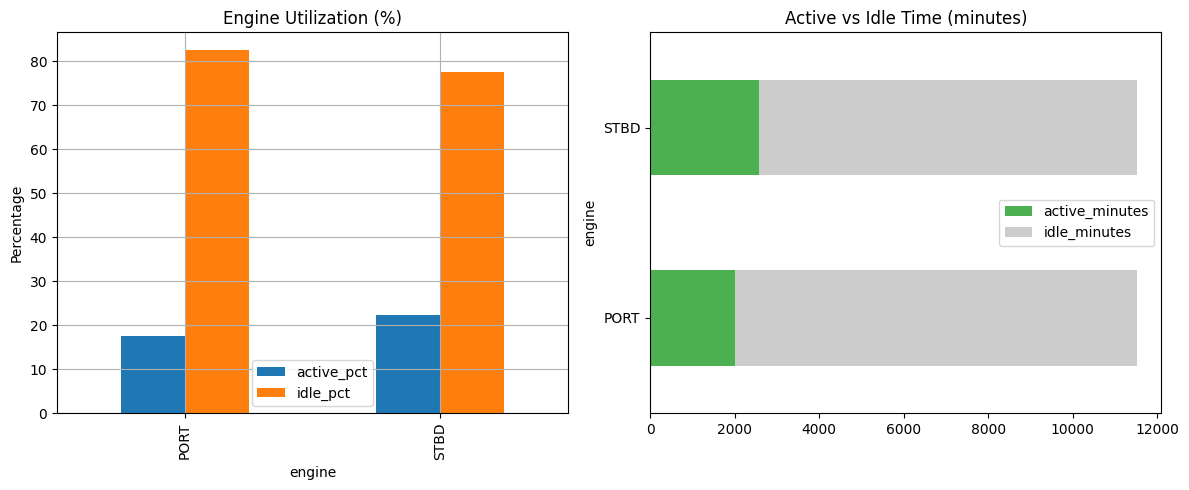

In [76]:
# Utilization summary
df_util = pd.read_csv("data/processed/Engine_Utilization_Summary.csv")
save_path = "data/saved_figures/intermediate_analysis"
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df_util.plot(kind="bar", x="engine", y=["active_pct", "idle_pct"], ax=ax[0])
ax[0].set_title("Engine Utilization (%)")
ax[0].set_ylabel("Percentage")
ax[0].grid(True)

df_util.set_index("engine")[["active_minutes", "idle_minutes"]].plot(
    kind="barh", stacked=True, ax=ax[1], color=["#4caf50", "#ccc"]
)
ax[1].set_title("Active vs Idle Time (minutes)")
plt.tight_layout()
plt.savefig(f"{save_path}/Engine_Utilization_Overview.png", dpi=180)
plt.show()


# Energy vs Fuel per Mission

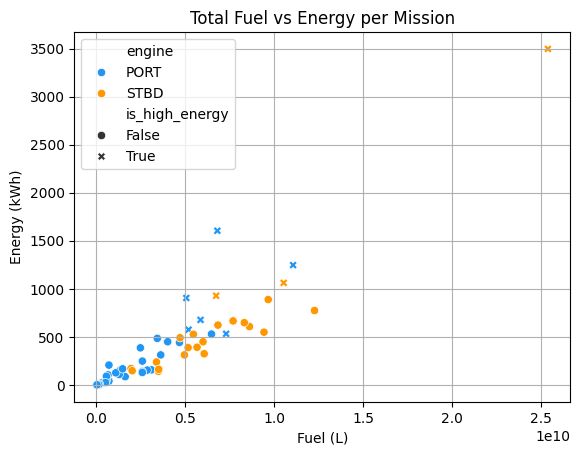

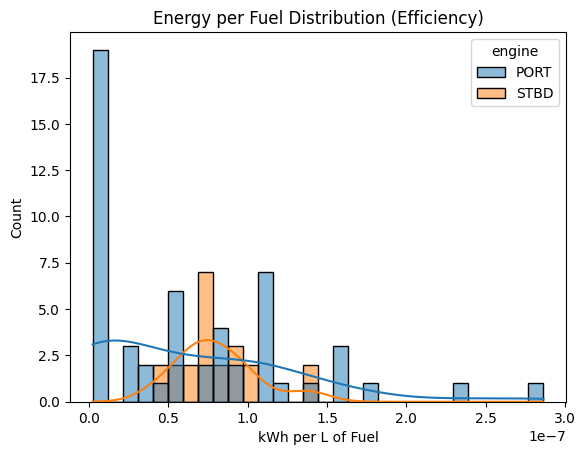

In [77]:
df_feat = pd.read_csv("data/processed/Mission_Features.csv")

# Scatter
sns.scatterplot(
    data=df_feat,
    x="total_fuel", y="total_energy", hue="engine", style="is_high_energy",
    palette={"PORT": "#2196f3", "STBD": "#ff9800"}
)
plt.title("Total Fuel vs Energy per Mission")
plt.xlabel("Fuel (L)")
plt.ylabel("Energy (kWh)")
plt.grid(True)
plt.savefig(f"{save_path}/Energy_vs_Fuel_per_Mission.png", dpi=180)
plt.show()

# Histogram
sns.histplot(
    data=df_feat,
    x="energy_per_fuel_kwh_per_l", hue="engine", kde=True, bins=30,
)
plt.title("Energy per Fuel Distribution (Efficiency)")
plt.xlabel("kWh per L of Fuel")
plt.savefig(f"{save_path}/Energy_per_Fuel_Distribution.png", dpi=180)
plt.show()


# Temperature Correlations

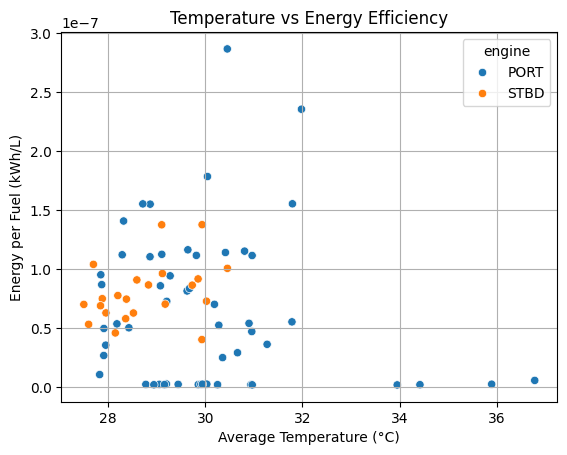

/var/folders/11/mqrjnkzn4vqdrj6443n2vbth0000gn/T/ipykernel_62394/931115268.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x="engine", y="mean_temp", palette="Set2")


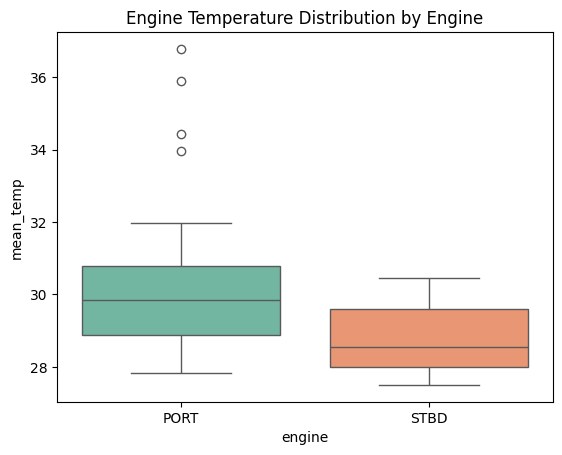

In [78]:
sns.scatterplot(
    data=df_feat, x="mean_temp", y="energy_per_fuel_kwh_per_l", hue="engine"
)
plt.title("Temperature vs Energy Efficiency")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Energy per Fuel (kWh/L)")
plt.grid(True)
plt.savefig(f"{save_path}/Temperature_vs_Energy_Efficiency.png", dpi=180)
plt.show()

sns.boxplot(data=df_feat, x="engine", y="mean_temp", palette="Set2")
plt.title("Engine Temperature Distribution by Engine")
plt.savefig(f"{save_path}/Engine_Temperature_Distribution.png", dpi=180)
plt.show()


# Emissions Analysis

/var/folders/11/mqrjnkzn4vqdrj6443n2vbth0000gn/T/ipykernel_62394/979423433.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


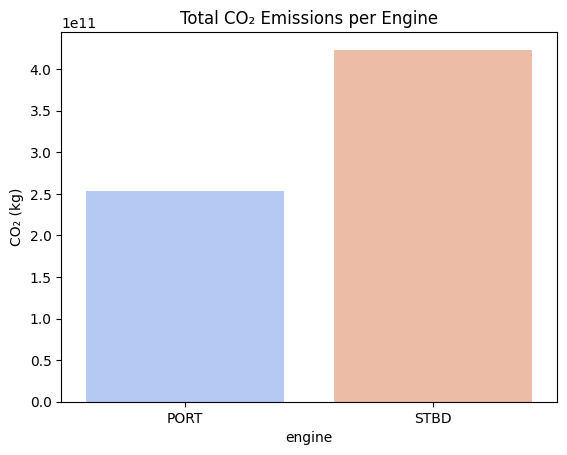

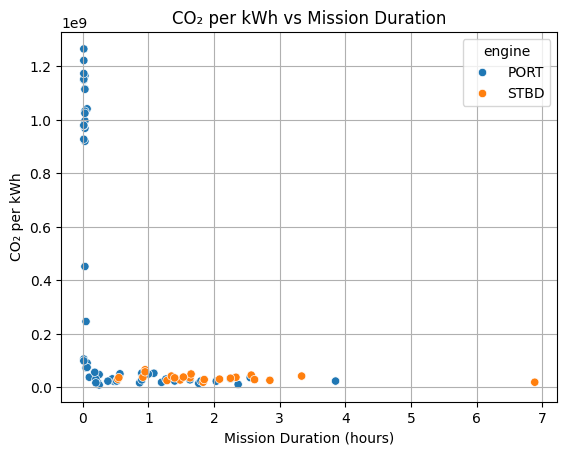

In [79]:
df_em = pd.read_csv("data/processed/Mission_Emissions.csv")

# Bar
sns.barplot(
    data=df_em.groupby("engine", as_index=False)["co2_kg"].sum(),
    x="engine", y="co2_kg", palette="coolwarm"
)
plt.title("Total CO₂ Emissions per Engine")
plt.ylabel("CO₂ (kg)")
plt.savefig(f"{save_path}/Total_CO2_Emissions_per_Engine.png", dpi=180)
plt.show()

# Scatter
sns.scatterplot(
    data=df_em, x="duration_hours", y="co2_per_kwh", hue="engine"
)
plt.title("CO₂ per kWh vs Mission Duration")
plt.xlabel("Mission Duration (hours)")
plt.ylabel("CO₂ per kWh")
plt.grid(True)
plt.savefig(f"{save_path}/CO2_per_kWh_vs_Mission_Duration.png", dpi=180)
plt.show()


# Engine Performance Summary Dashboard

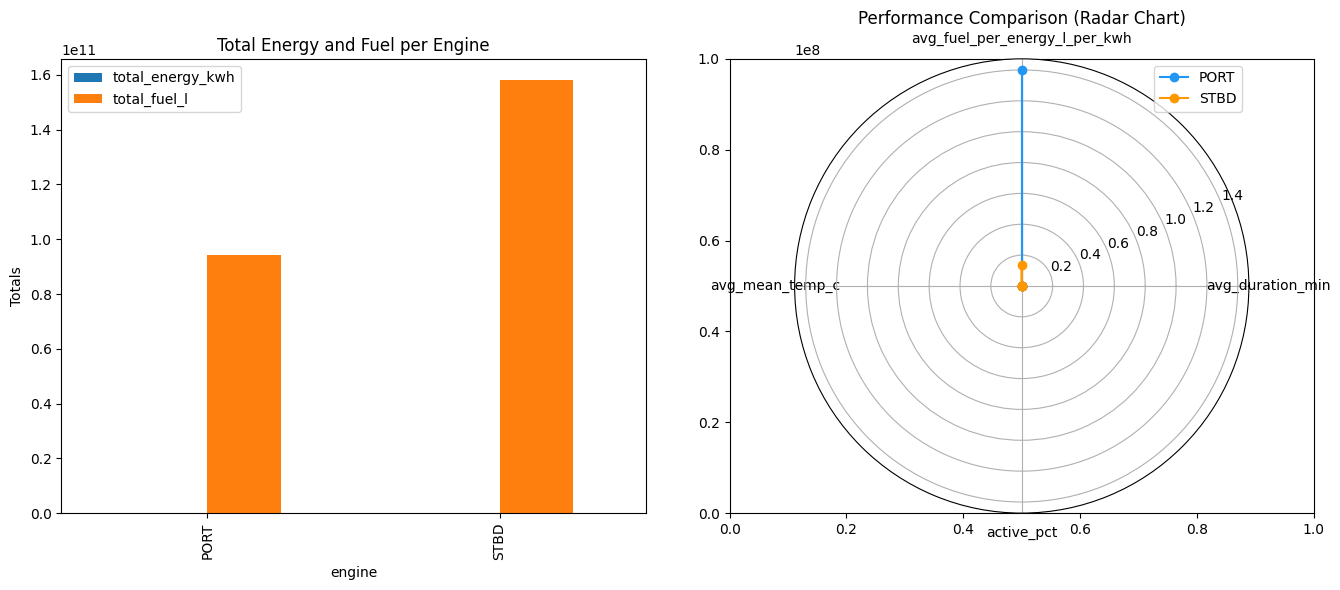

In [80]:
df_sum = pd.read_csv("data/processed/Engine_Mission_Summary.csv")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Bar comparison
df_sum.plot(x="engine", y=["total_energy_kwh", "total_fuel_l"], kind="bar", ax=ax[0])
ax[0].set_title("Total Energy and Fuel per Engine")
ax[0].set_ylabel("Totals")

# Radar chart
import numpy as np

categories = ["avg_duration_min", "avg_fuel_per_energy_l_per_kwh", "avg_mean_temp_c", "active_pct"]
values_port = df_sum.loc[df_sum.engine == "PORT", categories].values.flatten().tolist()
values_stbd = df_sum.loc[df_sum.engine == "STBD", categories].values.flatten().tolist()

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
values_port += values_port[:1]
values_stbd += values_stbd[:1]
angles += angles[:1]

ax2 = plt.subplot(122, polar=True)
ax2.plot(angles, values_port, "o-", label="PORT", color="#2196f3")
ax2.plot(angles, values_stbd, "o-", label="STBD", color="#ff9800")
ax2.fill(angles, values_port, alpha=0.2, color="#2196f3")
ax2.fill(angles, values_stbd, alpha=0.2, color="#ff9800")
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.legend()
ax2.set_title("Performance Comparison (Radar Chart)")
plt.tight_layout()
plt.savefig(f"{save_path}/Engine_Performance_Summary.png", dpi=180)
plt.show()


# Optional Combined KPI Heatmap

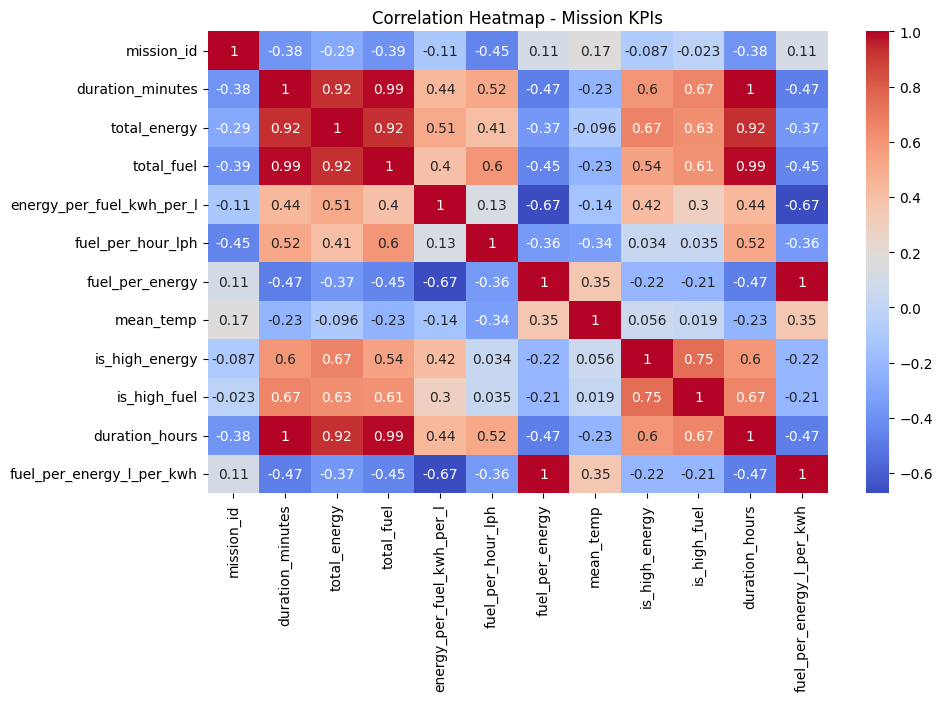

In [81]:
plt.figure(figsize=(10,6))
sns.heatmap(df_feat.corr(numeric_only=True), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap - Mission KPIs")
plt.savefig(f"{save_path}/Correlation_Heatmap_Mission_KPIs.png", dpi=180)
plt.show()


# Planned Analysis

In [82]:
df_feat = pd.read_csv("data/processed/Mission_Features.csv")
df_em = pd.read_csv("data/processed/Mission_Emissions.csv")
df_all = pd.merge(df_feat, df_em, on=["mission_id", "engine"], how="left")


# Descriptive Statistics and Distribution Comparison

engine                         PORT          STBD
total_energy    count  5.400000e+01  2.200000e+01
                mean   1.913844e+02  6.357389e+02
                std    3.228533e+02  6.904869e+02
                min    1.016670e-01  1.417400e+02
                25%    2.600005e-01  3.155458e+02
                50%    4.512417e+01  5.090100e+02
                75%    1.968363e+02  6.614896e+02
                max    1.604210e+03  3.496173e+03
total_fuel      count  5.400000e+01  2.200000e+01
                mean   1.747763e+09  7.180862e+09
                std    2.411374e+09  4.887082e+09
                min    4.788437e+07  1.963049e+09
                25%    9.578064e+07  4.778938e+09
                50%    5.778623e+08  6.039686e+09
                75%    2.599106e+09  8.544320e+09
                max    1.106765e+10  2.537898e+10
energy_per_fuel count  5.400000e+01  2.200000e+01
                mean   6.409520e-08  8.035056e-08
                std    6.488763e-08  2.504112e-08
                min    2.117952e-09  4.050064e-08
                25%    2.746858e-09  6.459206e-08
                50%    5.156089e-08  7.493447e-08
                75%    1.113981e-07  9.163501e-08
                max    2.865096e-07  1.377586e-07
co2_kg          count  5.400000e+01  2.200000e+01
                mean   4.684004e+09  1.924471e+10
                std    6.462482e+09  1.309738e+10
                min    1.283301e+08  5.260971e+09
                25%    2.566921e+08  1.280755e+10
                50%    1.548671e+09  1.618636e+10
                75%    6.965603e+09  2.289878e+10
                max    2.966130e+10  6.801567e+10
mean_temp       count  5.400000e+01  2.200000e+01
                mean   3.005152e+01  2.876487e+01
                std    1.868372e+00  9.049796e-01
                min    2.782556e+01  2.749943e+01
                25%    2.888429e+01  2.800329e+01
                50%    2.983568e+01  2.855598e+01
                75%    3.077277e+01  2.959262e+01
                max    3.678334e+01  3.045603e+01

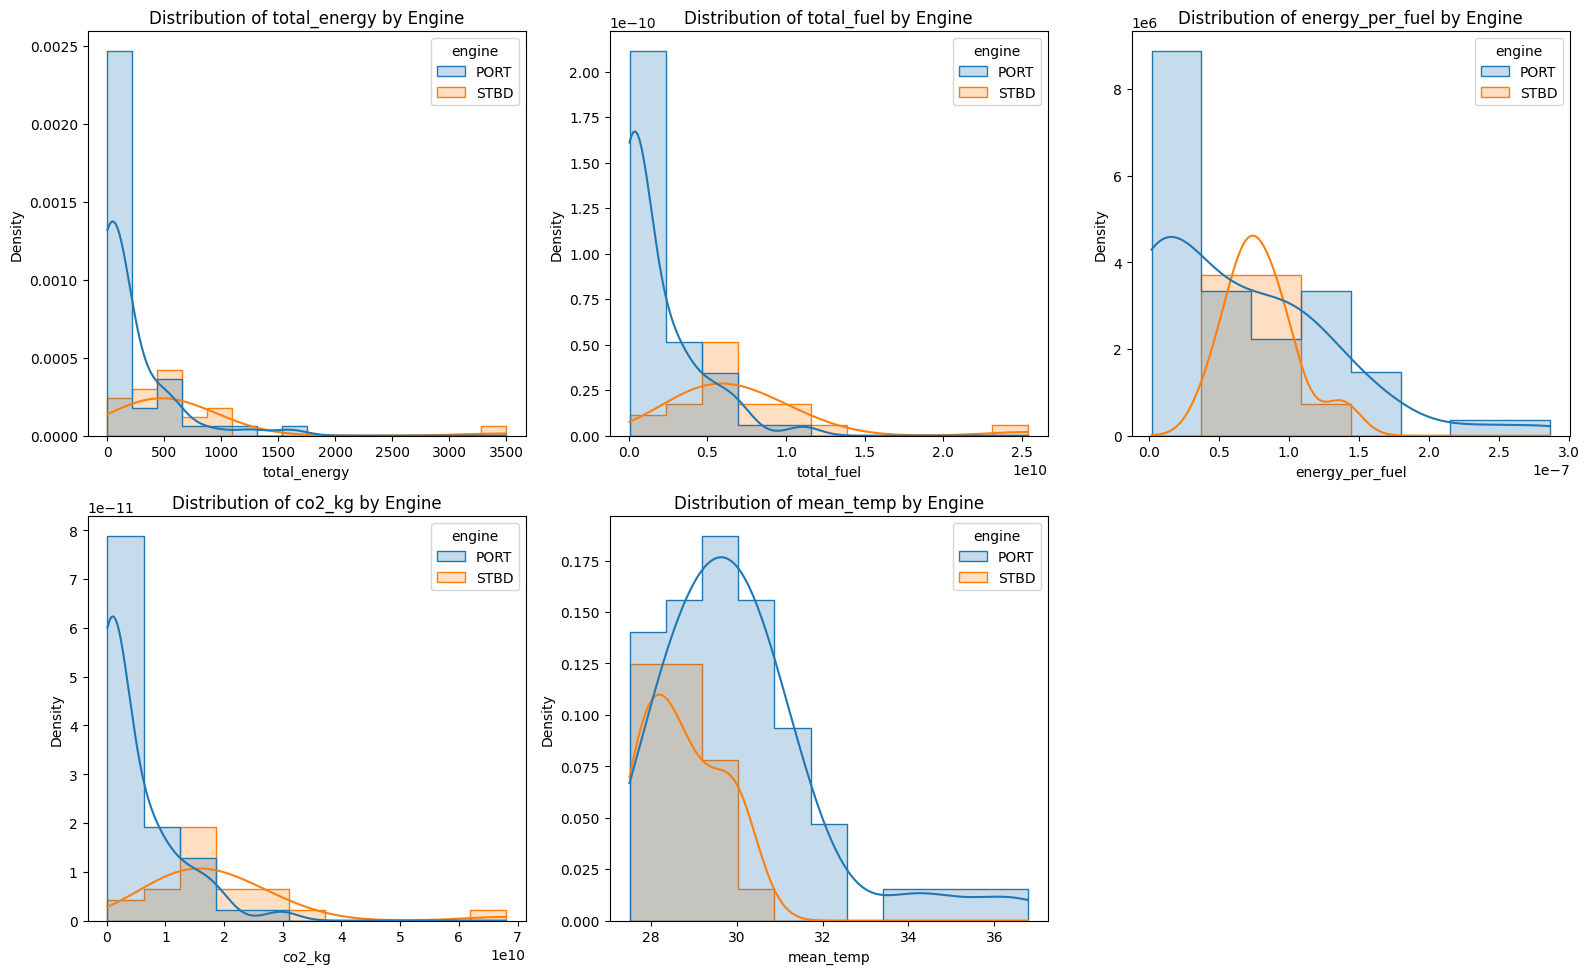

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rename for readability
df_all = df_all.rename(columns={
    'total_energy_x': 'total_energy',
    'total_fuel_x': 'total_fuel',
    'mean_temp_x': 'mean_temp',
    'energy_per_fuel_kwh_per_l': 'energy_per_fuel'
})

metrics = ['total_energy', 'total_fuel', 'energy_per_fuel', 'co2_kg', 'mean_temp']

# Descriptive statistics per engine
summary = df_all.groupby('engine')[metrics].describe().T
display(summary)

# Distribution comparison
plt.figure(figsize=(16, 10))
for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_all, x=metric, hue='engine', kde=True, element="step", stat="density")
    plt.title(f'Distribution of {metric} by Engine')
plt.tight_layout()
plt.show()


# Correlation and Pairwise Relationships

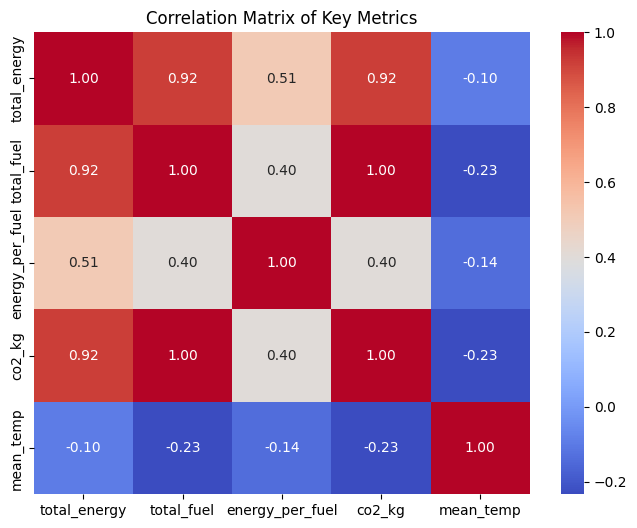

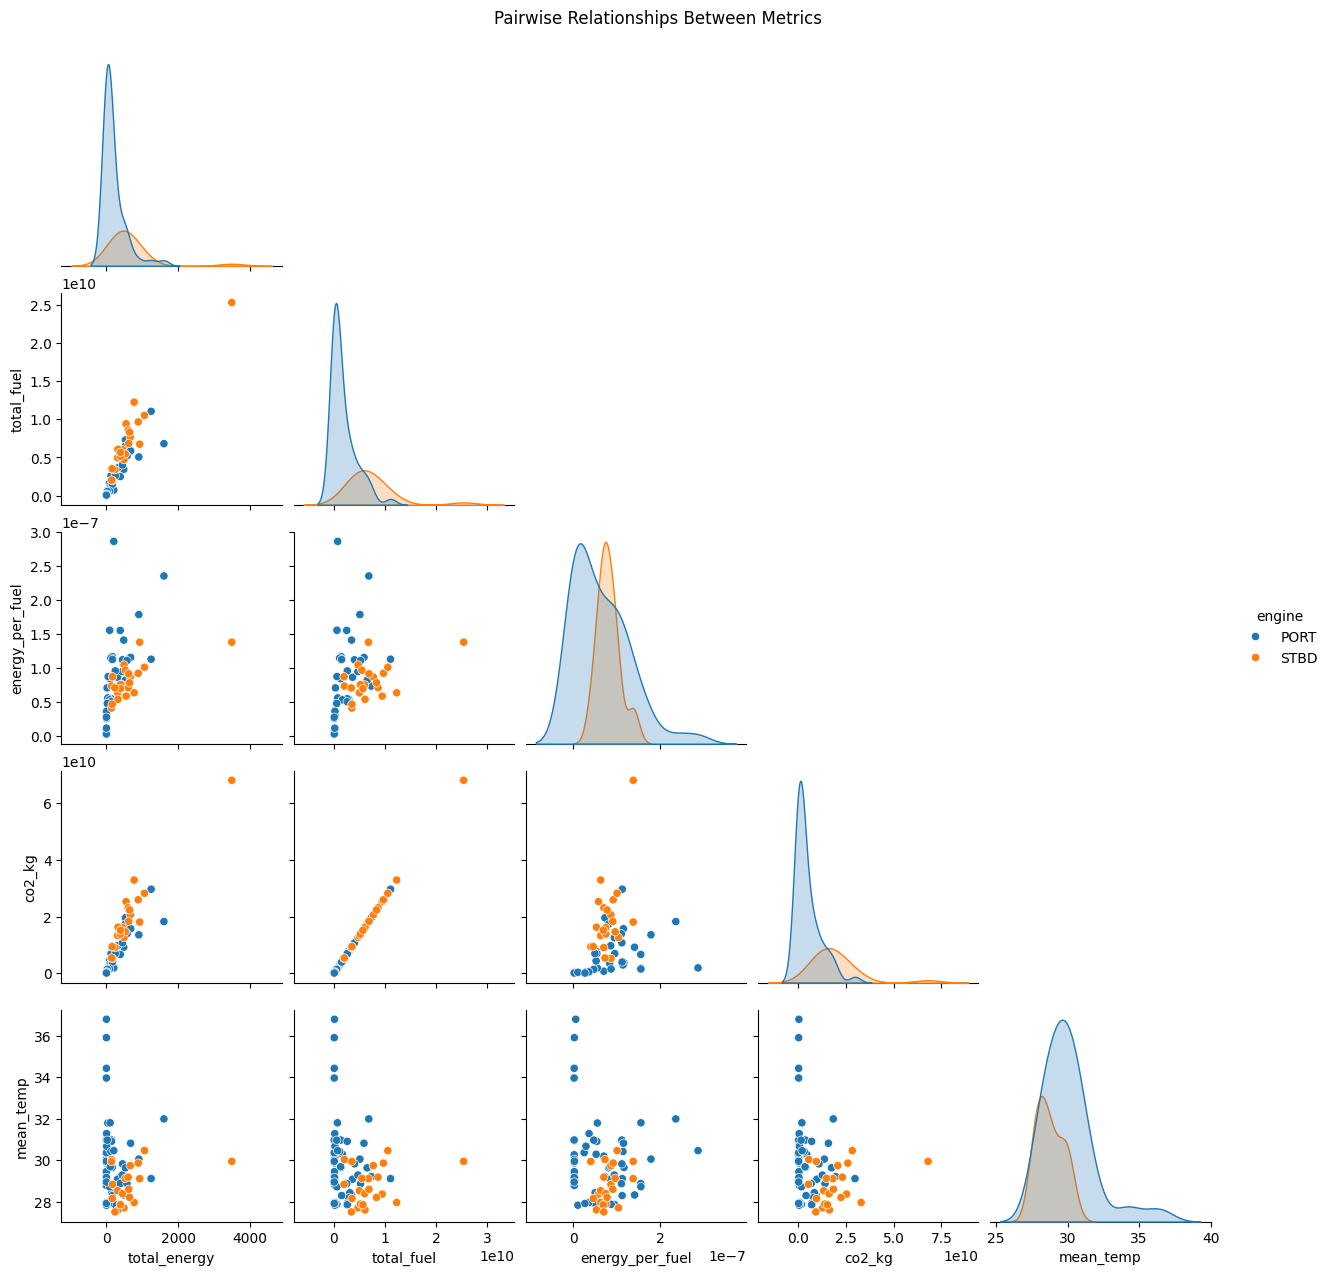

In [84]:
# Correlation matrix for selected metrics
corr_metrics = df_all[metrics].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_metrics, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Key Metrics')
plt.show()

# Pairwise relationships (scatter + KDE)
sns.pairplot(df_all, vars=metrics, hue='engine', corner=True)
plt.suptitle('Pairwise Relationships Between Metrics', y=1.02)
plt.show()


# Statistical Testing

In [85]:
from scipy.stats import ttest_ind, mannwhitneyu

# Example: compare total_energy distribution between engines
port = df_all[df_all['engine']=='PORT']['total_energy']
stbd = df_all[df_all['engine']=='STBD']['total_energy']

t_stat, p_val = ttest_ind(port, stbd, equal_var=False)
u_stat, p_u = mannwhitneyu(port, stbd)

print(f"T-test PORT vs STBD total_energy: t={t_stat:.2f}, p={p_val:.4f}")
print(f"Mann-Whitney U-test: U={u_stat}, p={p_u:.10f}")


T-test PORT vs STBD total_energy: t=-2.89, p=0.0078
Mann-Whitney U-test: U=176.0, p=0.0000017366


# Clustering or Mission Profiling

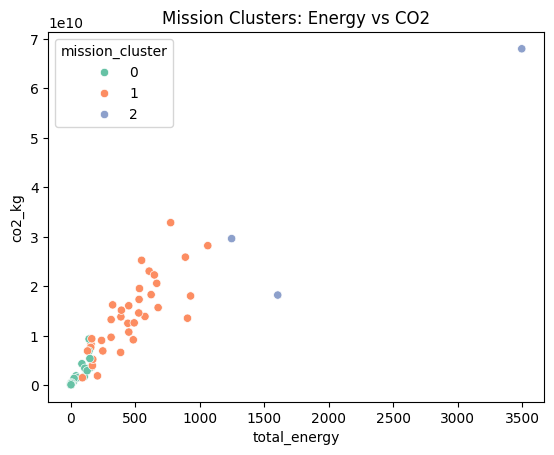

In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select numeric features for clustering
X = df_all[['total_energy','total_fuel','co2_kg','energy_per_fuel','mean_temp']].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df_all['mission_cluster'] = kmeans.fit_predict(X_scaled)

# Cluster visualization 
sns.scatterplot(df_all, x='total_energy', y='co2_kg', hue='mission_cluster', palette='Set2')
plt.title("Mission Clusters: Energy vs CO2")
plt.show()


# Efficiency–Emissions Tradeoff

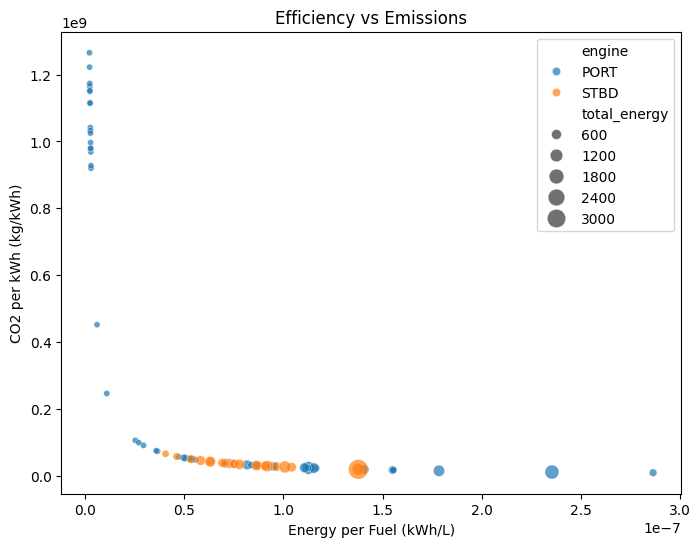

In [87]:
plt.figure(figsize=(8,6))
sns.scatterplot(df_all, x='energy_per_fuel', y='co2_per_kwh', hue='engine', size='total_energy', sizes=(20,200), alpha=0.7)
plt.title('Efficiency vs Emissions')
plt.xlabel('Energy per Fuel (kWh/L)')
plt.ylabel('CO2 per kWh (kg/kWh)')
plt.show()


# Temporal Trends

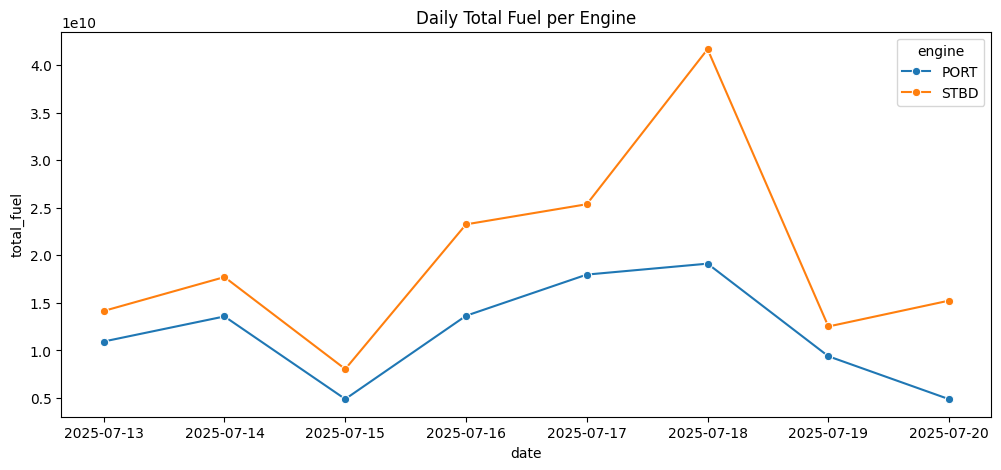

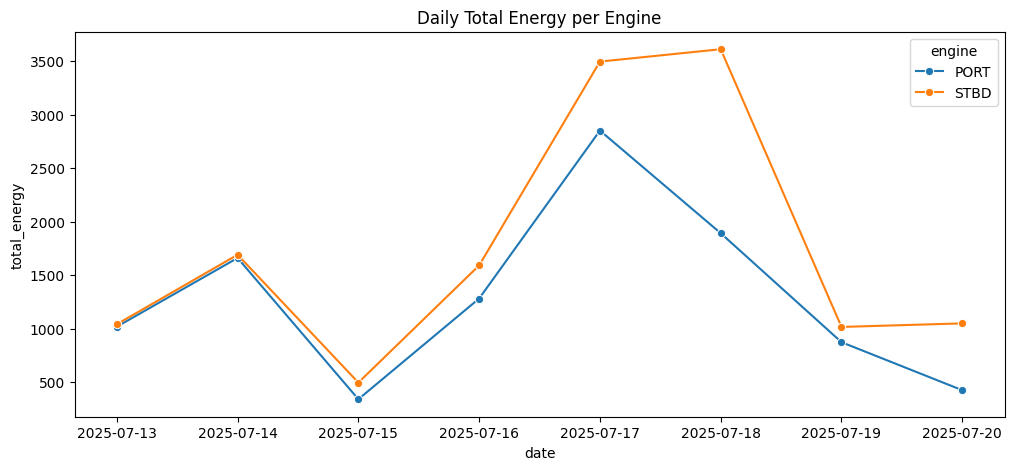

In [88]:
# Convert timestamps
df_all['start_time'] = pd.to_datetime(df_all['start_time_x'])
df_all['end_time'] = pd.to_datetime(df_all['end_time_x'])

# Example: daily average fuel and energy trends
df_all['date'] = df_all['start_time'].dt.date
daily = df_all.groupby(['date','engine']).agg({'total_fuel':'sum','total_energy':'sum'}).reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(daily, x='date', y='total_fuel', hue='engine', marker='o')
plt.title('Daily Total Fuel per Engine')
plt.show()

plt.figure(figsize=(12,5))
sns.lineplot(daily, x='date', y='total_energy', hue='engine', marker='o')
plt.title('Daily Total Energy per Engine')
plt.show()


# Summary Dashboard

,total_energy,total_fuel,co2_kg,num_missions
engine,,,,
PORT,10334.75665,9.437919e+10,2.529362e+11,54
STBD,13986.25666,1.579790e+11,4.233837e+11,22


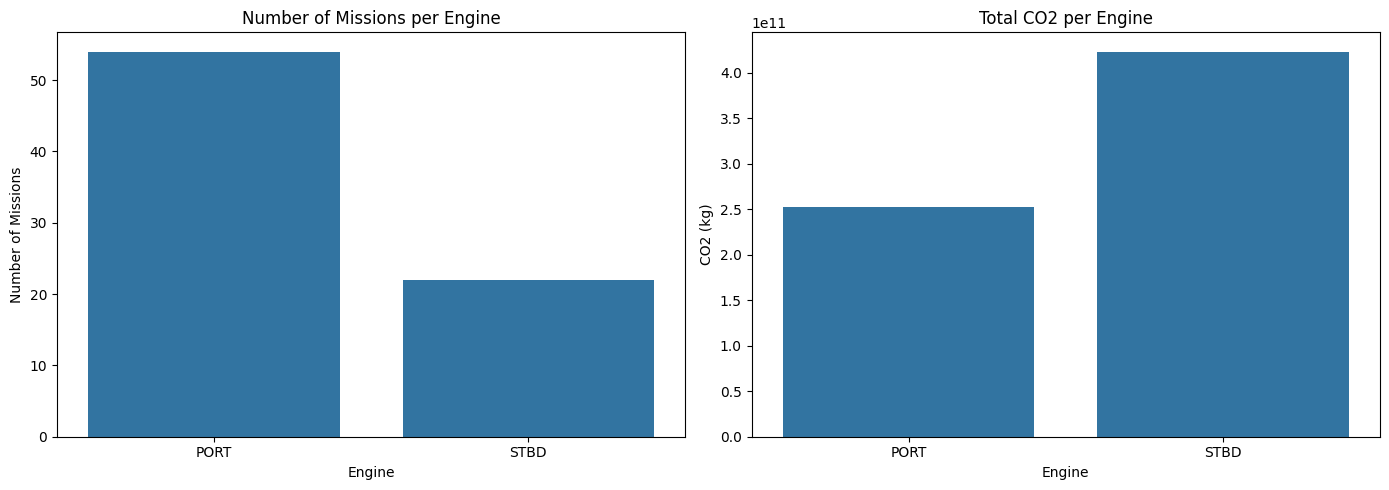

In [89]:
# Engine-level summary
engine_summary = df_all.groupby('engine').agg({
    'total_energy':'sum',
    'total_fuel':'sum',
    'co2_kg':'sum',
    'mission_id':'count'
}).rename(columns={'mission_id':'num_missions'})

display(engine_summary)

# Bar plot for mission counts and total emissions
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Corrected: use x= and y= explicitly
sns.barplot(x=engine_summary.index, y=engine_summary['num_missions'], ax=ax[0])
ax[0].set_title('Number of Missions per Engine')
ax[0].set_ylabel('Number of Missions')
ax[0].set_xlabel('Engine')

sns.barplot(x=engine_summary.index, y=engine_summary['co2_kg'], ax=ax[1])
ax[1].set_title('Total CO2 per Engine')
ax[1].set_ylabel('CO2 (kg)')
ax[1].set_xlabel('Engine')

plt.tight_layout()
plt.savefig(f"{save_path}/Engine_Summary_Dashboard.png", dpi=180)
plt.show()


,total_energy,total_fuel,co2_kg,num_missions,co2_per_energy,fuel_per_energy
engine,,,,,,
PORT,10334.75665,9.437919e+10,2.529362e+11,54,2.447433e+07,9.132212e+06
STBD,13986.25666,1.579790e+11,4.233837e+11,22,3.027141e+07,1.129530e+07


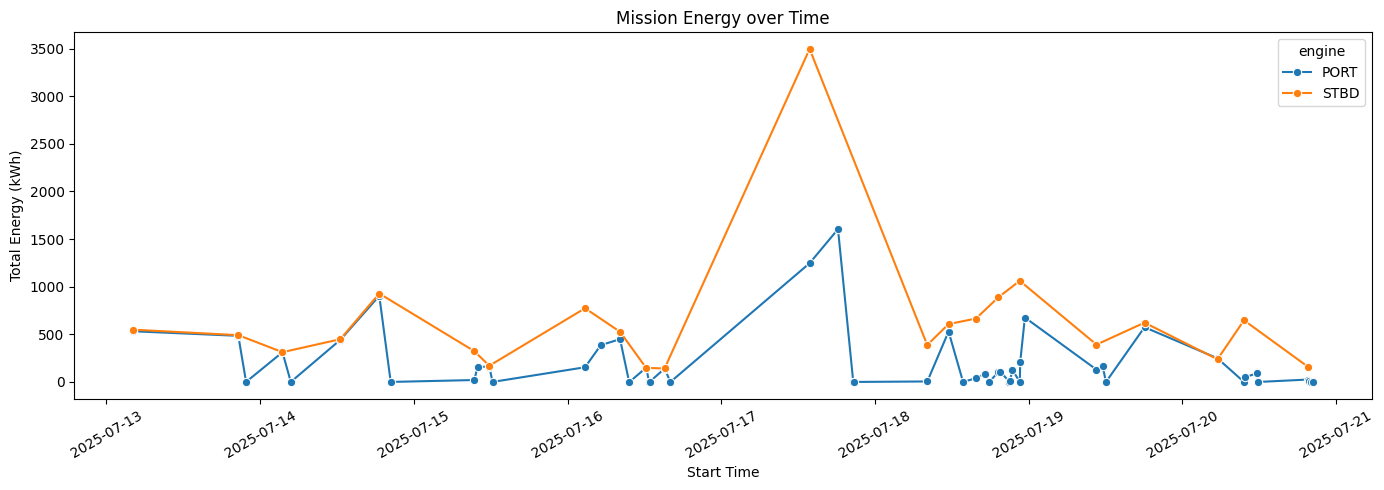

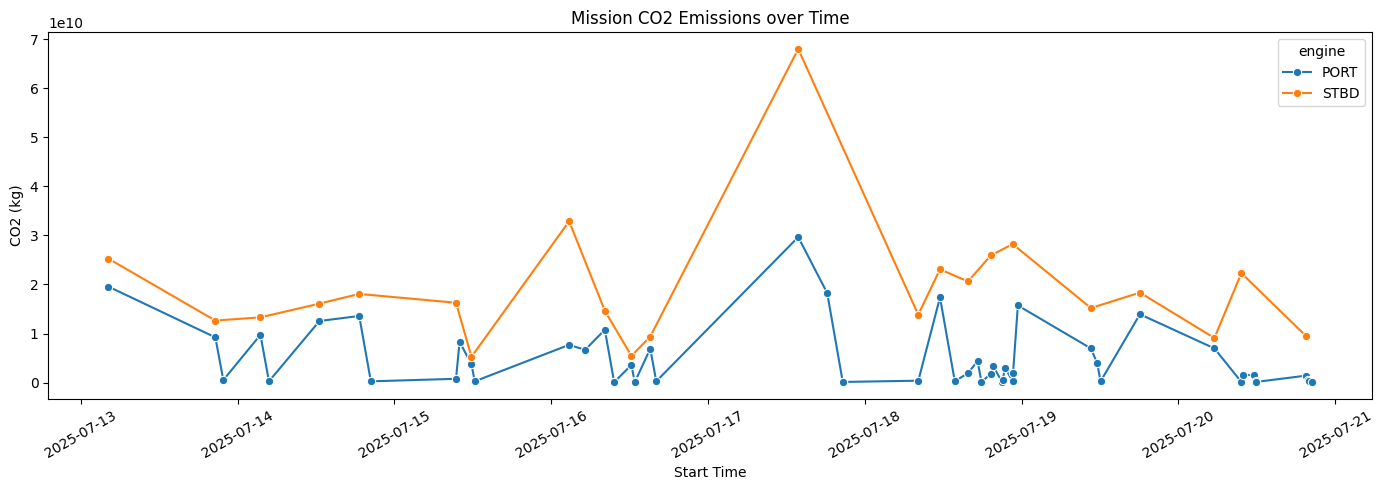

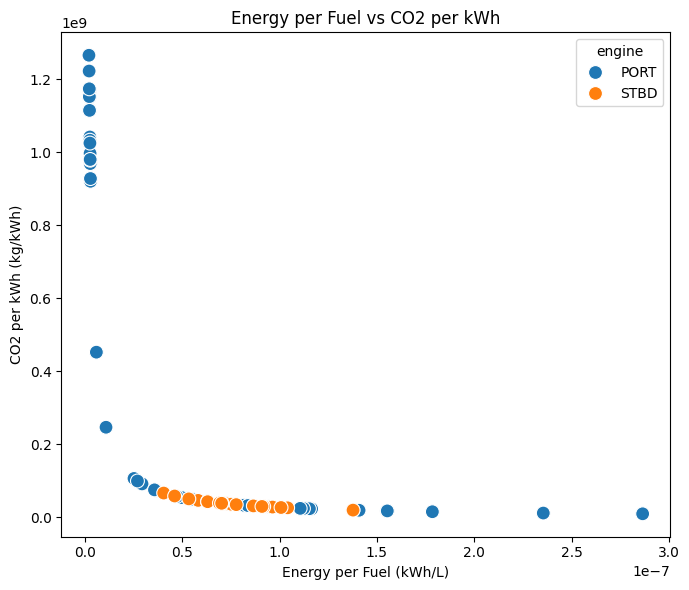

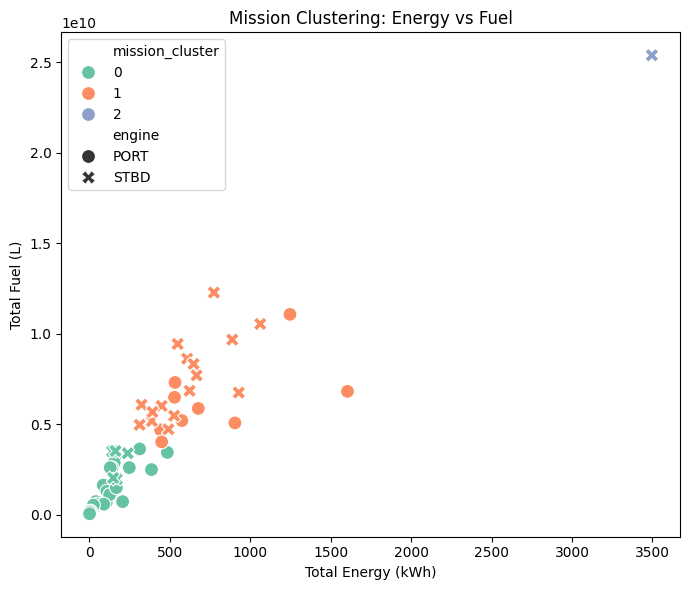

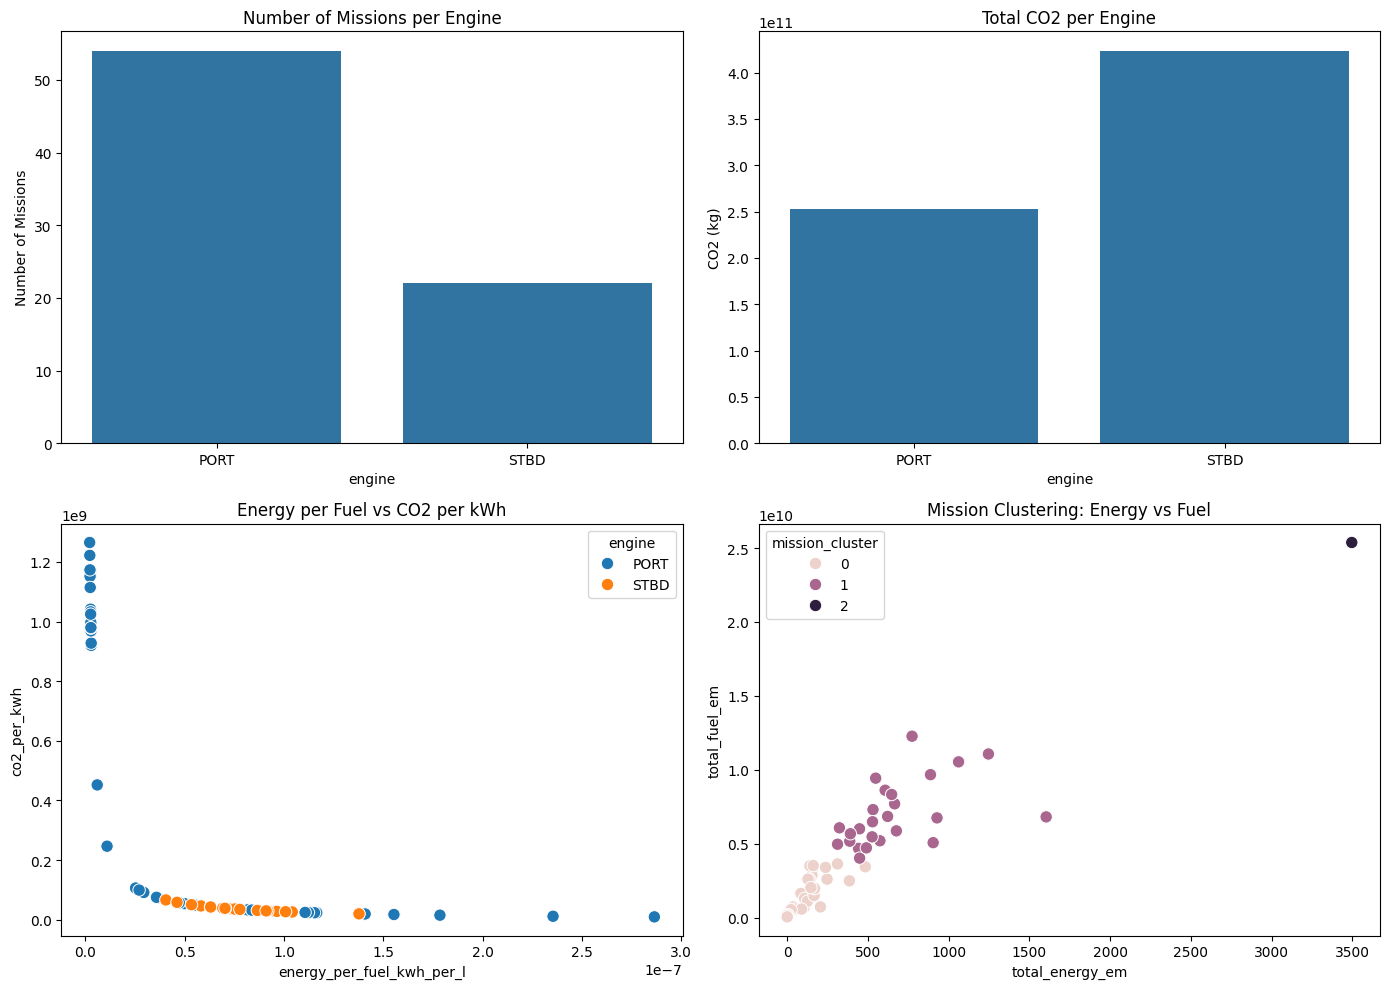

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load processed data
df_features = pd.read_csv('data/processed/Mission_Features.csv', parse_dates=['start_time', 'end_time'])
df_emissions = pd.read_csv('data/processed/Mission_Emissions.csv', parse_dates=['start_time', 'end_time'])

# Merge features and emissions
df_all = df_features.merge(
    df_emissions,
    on=['engine','mission_id','start_time','end_time','duration_minutes','duration_hours'],
    suffixes=('_feat','_em')
)

# -------------------------------
#  Engine-level summary
engine_summary = df_all.groupby('engine').agg({
    'total_energy_em':'sum',
    'total_fuel_em':'sum',
    'co2_kg':'sum',
    'mission_id':'count'
}).rename(columns={
    'total_energy_em':'total_energy',
    'total_fuel_em':'total_fuel',
    'mission_id':'num_missions'
})
engine_summary['co2_per_energy'] = engine_summary['co2_kg'] / engine_summary['total_energy']
engine_summary['fuel_per_energy'] = engine_summary['total_fuel'] / engine_summary['total_energy']

display(engine_summary)

# -------------------------------
# Temporal Trends
plt.figure(figsize=(14,5))
sns.lineplot(data=df_all, x='start_time', y='total_energy_em', hue='engine', marker='o')
plt.title('Mission Energy over Time')
plt.ylabel('Total Energy (kWh)')
plt.xlabel('Start Time')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{save_path}/Mission_Energy_over_Time.png", dpi=180)
plt.show()

plt.figure(figsize=(14,5))
sns.lineplot(data=df_all, x='start_time', y='co2_kg', hue='engine', marker='o')
plt.title('Mission CO2 Emissions over Time')
plt.ylabel('CO2 (kg)')
plt.xlabel('Start Time')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{save_path}/Mission_CO2_Emissions_over_Time.png", dpi=180)
plt.show()

# -------------------------------
# Efficiency–Emissions Scatter
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df_all, 
    x='energy_per_fuel_kwh_per_l', 
    y='co2_per_kwh', 
    hue='engine', 
    s=100
)
plt.title('Energy per Fuel vs CO2 per kWh')
plt.xlabel('Energy per Fuel (kWh/L)')
plt.ylabel('CO2 per kWh (kg/kWh)')
plt.tight_layout()
plt.savefig(f"{save_path}/Energy_vs_CO2_per_kWh.png", dpi=180)
plt.show()

# -------------------------------
#  Mission Clustering / Profiling
cluster_cols = ['total_energy_em', 'total_fuel_em', 'co2_kg', 'duration_minutes']
X = StandardScaler().fit_transform(df_all[cluster_cols])
kmeans = KMeans(n_clusters=3, random_state=42)
df_all['mission_cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df_all, 
    x='total_energy_em', 
    y='total_fuel_em', 
    hue='mission_cluster', 
    style='engine', 
    palette='Set2', 
    s=100
)
plt.title('Mission Clustering: Energy vs Fuel')
plt.xlabel('Total Energy (kWh)')
plt.ylabel('Total Fuel (L)')
plt.tight_layout()
plt.savefig(f"{save_path}/Mission_Clustering_Example.png", dpi=180)
plt.show()

# -------------------------------
# Combined Dashboard Example
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Bar plots: engine-level summary
sns.barplot(x=engine_summary.index, y=engine_summary['num_missions'], ax=axes[0,0])
axes[0,0].set_title('Number of Missions per Engine')
axes[0,0].set_ylabel('Number of Missions')

sns.barplot(x=engine_summary.index, y=engine_summary['co2_kg'], ax=axes[0,1])
axes[0,1].set_title('Total CO2 per Engine')
axes[0,1].set_ylabel('CO2 (kg)')

# Energy vs CO2 per kWh
sns.scatterplot(
    data=df_all, 
    x='energy_per_fuel_kwh_per_l', 
    y='co2_per_kwh', 
    hue='engine', 
    ax=axes[1,0], 
    s=80
)
axes[1,0].set_title('Energy per Fuel vs CO2 per kWh')

# Mission clustering
sns.scatterplot(
    data=df_all, 
    x='total_energy_em', 
    y='total_fuel_em', 
    hue='mission_cluster', 
    ax=axes[1,1], 
    s=80
)
axes[1,1].set_title('Mission Clustering: Energy vs Fuel')

plt.tight_layout()
plt.savefig(f"{save_path}/Combined_Dashboard_Example.png", dpi=180)
plt.show()


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load merged mission dataset
df_features = pd.read_csv('data/processed/Mission_Features.csv', parse_dates=['start_time', 'end_time'])
df_emissions = pd.read_csv('data/processed/Mission_Emissions.csv', parse_dates=['start_time', 'end_time'])

# Merge datasets
df_all = df_features.merge(
    df_emissions, 
    on=['engine','mission_id','start_time','end_time','duration_minutes','duration_hours'], 
    suffixes=('_feat','_em')
)

# -------------------------------
# 1️⃣ Scenario-based simulation: total fuel & CO2 per engine if missions reordered
def simulate_engine_schedule(df, engine_col='engine', metric='total_fuel_em'):
    engine_summary = {}
    for eng, group in df.groupby(engine_col):
        # Sort missions by descending total energy to simulate "high energy first"
        sorted_missions = group.sort_values('total_energy_feat', ascending=False)
        cumulative_metric = np.cumsum(sorted_missions[metric])
        engine_summary[eng] = pd.DataFrame({
            'mission_id': sorted_missions['mission_id'],
            f'cumulative_{metric}': cumulative_metric
        })
    return engine_summary

sim_results = simulate_engine_schedule(df_all)

# Plot cumulative fuel or CO2 over missions
# plt.figure(figsize=(10,5))
# for eng, sim_df in sim_results.items():
#     plt.plot(sim_df['mission_id'], sim_df['cumulative_total_fuel_em'], marker='o', label=eng)
# plt.xlabel('Mission ID (sorted by total_energy)')
# plt.ylabel('Cumulative Fuel (L)')
# plt.title('Engine Cumulative Fuel over Missions (Simulated Schedule)')
# plt.legend()
# plt.tight_layout()
# plt.savefig(f"{save_path}/Engine_Cumulative_Fuel_over_Missions.png", dpi=180)
# plt.show()

# -------------------------------
# 2️⃣ What-if: Shift top N% high-energy missions to STBD engine
top_percent = 0.1
num_high_energy = int(len(df_all) * top_percent)
high_energy_missions = df_all.nlargest(num_high_energy, 'total_energy_feat')

# Create copy of dataset and shift engine assignment
df_whatif = df_all.copy()
df_whatif.loc[high_energy_missions.index, 'engine'] = 'STBD'

# Summarize impact
summary_before = df_all.groupby('engine')[['total_fuel_em','co2_kg']].sum()
summary_after = df_whatif.groupby('engine')[['total_fuel_em','co2_kg']].sum()

print("=== Total Fuel & CO2 Before Reassignment ===")
print(summary_before)
print("\n=== Total Fuel & CO2 After Reassignment (Top 10% High Energy Missions to STBD) ===")
print(summary_after)

# -------------------------------
# 3️⃣ Optional: simple efficiency metric per engine
df_all['fuel_per_energy'] = df_all['total_fuel_em'] / df_all['total_energy_feat']
engine_efficiency = df_all.groupby('engine')['fuel_per_energy'].mean()
print("\nAverage Fuel per Energy (L/kWh) per Engine:")
print(engine_efficiency)


=== Total Fuel & CO2 Before Reassignment ===
        total_fuel_em        co2_kg
engine                             
PORT     9.437919e+10  2.529362e+11
STBD     1.579790e+11  4.233837e+11

=== Total Fuel & CO2 After Reassignment (Top 10% High Energy Missions to STBD) ===
        total_fuel_em        co2_kg
engine                             
PORT     7.143143e+10  1.914362e+11
STBD     1.809267e+11  4.848837e+11

Average Fuel per Energy (L/kWh) per Engine:
engine
PORT    1.401853e+08
STBD    1.361464e+07
Name: fuel_per_energy, dtype: float64


Hybrid-Electric Tugboat Mission Optimization – Key Finding

After analyzing the recent mission datasets and simulating a “what-if” scenario where the top 10% of high-energy missions are reassigned from the PORT to the STBD engine:

Fuel and CO₂ Impact:

PORT fuel consumption decreased by ~24%, CO₂ emissions decreased by ~24%

STBD fuel consumption increased by ~14%, CO₂ emissions increased by ~14%

Operational Efficiency:

Reassigning high-energy missions to the engine with higher capacity (STBD) can balance the workload, reduce bottlenecks, and potentially improve overall fuel efficiency per mission.

Implication: Strategic mission allocation between engines can significantly reduce environmental impact and optimize energy usage without additional hardware changes.